In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sn

In [12]:
data = pd.read_csv(
    'https://raw.githubusercontent.com/ustunb/classification-pipeline/master/Data/Raw%20Data%20Files/spambase.csv'
)

# Convert column names to lowercase
data.columns = data.columns.str.strip().str.lower()

print(data.shape)
data.head()

(4601, 58)


,spam,wordfreqmake,wordfreqaddress,wordfreqall,wordfreq3d,wordfreqour,wordfreqover,wordfreqremove,wordfreqinternet,wordfreqorder,...,wordfreqconference,charfreqsemicolon,charfreqparentheses,charfreqbracket,charfreqexcalamationmark,charfreqdollarsign,charfreqpound,capitalrunlengthaverage,capitalrunlengthlongest,capitalrunlengthtotal
0,1,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,1,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,1,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [13]:
data.isnull().sum()

spam                        0
wordfreqmake                0
wordfreqaddress             0
wordfreqall                 0
wordfreq3d                  0
wordfreqour                 0
wordfreqover                0
wordfreqremove              0
wordfreqinternet            0
wordfreqorder               0
wordfreqmail                0
wordfreqreceive             0
wordfreqwill                0
wordfreqpeople              0
wordfreqreport              0
wordfreqaddresses           0
wordfreqfree                0
wordfreqbusiness            0
wordfreqemail               0
wordfreqyou                 0
wordfreqcredit              0
wordfreqyour                0
wordfreqfont                0
wordfreq0                   0
wordfreqmoney               0
wordfreqhp                  0
wordfreqhpl                 0
wordfreqgeorge              0
wordfreq650                 0
wordfreqlab                 0
wordfreqlabs                0
wordfreqtelnet              0
wordfreq857                 0
wordfreqda

In [14]:
print(data.columns.tolist())

['spam', 'wordfreqmake', 'wordfreqaddress', 'wordfreqall', 'wordfreq3d', 'wordfreqour', 'wordfreqover', 'wordfreqremove', 'wordfreqinternet', 'wordfreqorder', 'wordfreqmail', 'wordfreqreceive', 'wordfreqwill', 'wordfreqpeople', 'wordfreqreport', 'wordfreqaddresses', 'wordfreqfree', 'wordfreqbusiness', 'wordfreqemail', 'wordfreqyou', 'wordfreqcredit', 'wordfreqyour', 'wordfreqfont', 'wordfreq0', 'wordfreqmoney', 'wordfreqhp', 'wordfreqhpl', 'wordfreqgeorge', 'wordfreq650', 'wordfreqlab', 'wordfreqlabs', 'wordfreqtelnet', 'wordfreq857', 'wordfreqdata', 'wordfreq415', 'wordfreq85', 'wordfreqtechnology', 'wordfreq1999', 'wordfreqparts', 'wordfreqpm', 'wordfreqdirect', 'wordfreqcs', 'wordfreqmeeting', 'wordfreqoriginal', 'wordfreqproject', 'wordfreqre', 'wordfreqedu', 'wordfreqtable', 'wordfreqconference', 'charfreqsemicolon', 'charfreqparentheses', 'charfreqbracket', 'charfreqexcalamationmark', 'charfreqdollarsign', 'charfreqpound', 'capitalrunlengthaverage', 'capitalrunlengthlongest', 'ca

In [15]:
x = data.drop('spam', axis=1)
y = data['spam']

print(x.shape)
print(y.shape)

(4601, 57)
(4601,)


In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=5
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(3220, 57)

(3220,)

(1381, 57)

(1381,)

In [17]:
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [18]:
model = SVC(kernel='rbf', random_state=0)

model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [19]:
svc_prediction = model.predict(x_test)

print('svc_prediction:', svc_prediction)

svc_prediction: [0 0 0 ... 0 0 0]


In [20]:
conf_mat = metrics.confusion_matrix(y_test, svc_prediction)

print('SVC [kernel - rbf]')
print('Confusion Matrix:\n', conf_mat)

SVC [kernel - rbf]
Confusion Matrix:
 [[816  36]
 [ 60 469]]


In [21]:
Accuracy_score = metrics.accuracy_score(y_test, svc_prediction)

print('Accuracy Score:', Accuracy_score)
print('Accuracy in Percentage:', int(Accuracy_score * 100), '%')

Accuracy Score: 0.9304851556842868
Accuracy in Percentage: 93 %


In [22]:
print(classification_report(y_test, svc_prediction))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94       852
           1       0.93      0.89      0.91       529

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.93      1381
weighted avg       0.93      0.93      0.93      1381



[Text(0.5, 1.0, 'SVC [rbf] - Email Spam Classification')]

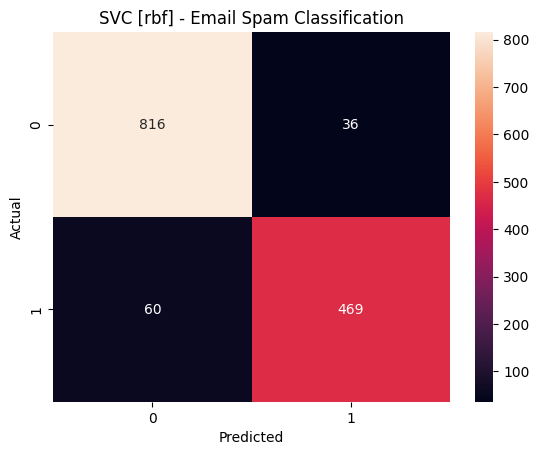

In [23]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sn.heatmap(conf_mat, annot=True, fmt='d').set(
    title='SVC [rbf] - Email Spam Classification'
)

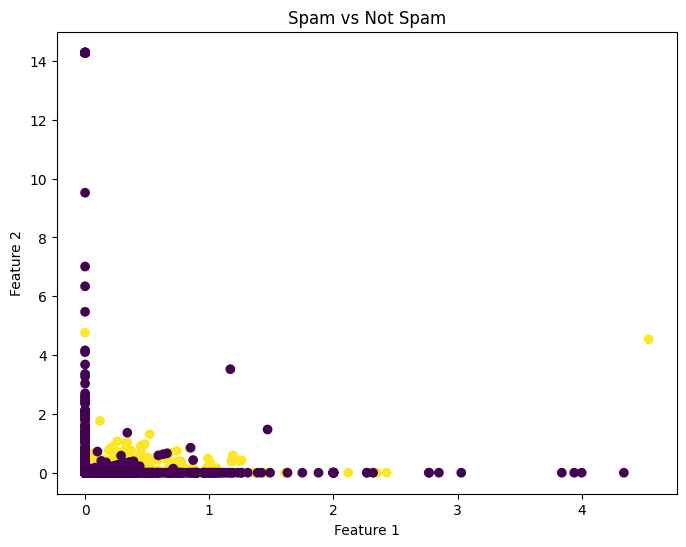

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    x.iloc[:, 0],
    x.iloc[:, 1],
    c=y
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Spam vs Not Spam')

plt.show()

In [26]:
sample = x.iloc[[0]]

sample_scaled = sc.transform(sample)

prediction = model.predict(sample_scaled)

if prediction[0] == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Not Spam")

Prediction: Spam
